# Iterative Retrieval and Question Refinement RAG

Iterative Retrieval RAG continuously interrogates the retrieval context. When the initial retrieval fails to provide sufficient factual depth, an autonomous query reformulation node analyzes information gaps, generates a refined query, and executes a second retrieval iteration before final answer generation.

## Workflow Architecture

<div align="center">
  <img src="workflow_iterative_retrieval.png" alt="Iterative Retrieval and Question Refinement RAG Architecture Diagram" width="580" />
</div>

<details>
<summary><b>Click to expand Colorful Mermaid Source Code</b></summary>

```mermaid
flowchart TD
    subgraph Input["Initial Query"]
        Q(["1. User Query"]):::startNode
    end
    subgraph Loop["Iterative Retrieval and Refinement Loop"]
        Retrieve["2. retrieve_docs Node<br/><b>FAISS + MiniLM</b><br/>(Fetches Context Chunks)"]:::retrieveNode
        Generate["3. generate_answer Node<br/><b>Groq LLM Drafting</b><br/>(Generates Candidate Response)"]:::genNode
        Verify["4. verify_answer Node<br/><b>Groq LLM Factuality Critic</b><br/>(Verifies Completeness)"]:::verifyNode
        Decision{"should_continue<br/>Verified or<br/>Max Attempts?"}:::decideNode
        Refine["5. refine_query Node<br/><b>Groq LLM Reformulation</b><br/>(Fills Information Gaps)"]:::refineNode
    end
    subgraph Output["Finalization"]
        Done["6. Final Verified Answer"]:::endNode
    end
    Q --> Retrieve
    Retrieve --> Generate
    Generate --> Verify
    Verify --> Decision
    Decision -->|Unverified and Attempts < 2| Refine
    Refine --> Retrieve
    Decision -->|Verified or Attempts >= 2| Done
    classDef startNode fill:#E8F5E9,stroke:#2E7D32,stroke-width:2px,color:#1B5E20;
    classDef retrieveNode fill:#E0F7FA,stroke:#00838F,stroke-width:2px,color:#004D40;
    classDef genNode fill:#E3F2FD,stroke:#1565C0,stroke-width:2px,color:#0D47A1;
    classDef verifyNode fill:#FFF8E1,stroke:#FFA000,stroke-width:2px,color:#E65100;
    classDef decideNode fill:#FCE4EC,stroke:#C2185B,stroke-width:2px,color:#880E4F;
    classDef refineNode fill:#EDE7F6,stroke:#5E35B1,stroke-width:2px,color:#311B92;
    classDef endNode fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#B71C1C;
```
</details>

### Key Architectural Highlights
- **Autonomous Query Reformulation**: Rewrites search queries dynamically based on previous answer critique.
- **Cumulative Evidence Stacking**: Combines initial and refined retrieval passages for comprehensive coverage.
- **Conditional State Routing**: LangGraph conditional routing terminates immediately upon factual verification.


In [15]:
import os
from typing import List
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import TextLoader
from langgraph.graph import StateGraph, END

In [16]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

### Load And Embed Documents
docs = TextLoader("research_notes.txt", encoding="utf-8").load()
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
vectorstore = FAISS.from_documents(chunks, HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2"))
retriever = vectorstore.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6829.71it/s]


In [17]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="groq:openai/gpt-oss-120b")
print("LLM ready")

LLM ready


In [18]:
from langchain_core.documents import Document

### Define Agent State

class IterativeRAGState(BaseModel):
    question: str
    refined_question: str = ""
    retrieved_docs: List[Document] = []
    answer: str = ""
    verified: bool = False
    attempts: int = 0

In [19]:
### Retrieve Node
def retrieve_docs(state: IterativeRAGState) -> IterativeRAGState:
    query = state.refined_question or state.question
    docs = retriever.invoke(query)
    return state.model_copy(update={"retrieved_docs": docs})

In [20]:
### Reflect And Verify
def generate_answer(state: IterativeRAGState) -> IterativeRAGState:
    
    context = "\n\n".join(doc.page_content for doc in state.retrieved_docs)
    prompt = f"""Use the following context to answer the question:

Context:
{context}

Question:
{state.question}
"""
    response = llm.invoke(prompt.strip()).content.strip()
    return state.model_copy(update={"answer": response, "attempts": state.attempts + 1})

In [21]:
## Reflect on answer
def reflect_on_answer(state: IterativeRAGState) -> IterativeRAGState:
    
    prompt = f"""
Evaluate whether the answer below is factually sufficient and complete.

Question: {state.question}
Answer: {state.answer}

Respond 'YES' if it's complete, otherwise 'NO' with feedback.
"""
    feedback = llm.invoke(prompt).content.lower()
    verified = "yes" in feedback
    return state.model_copy(update={"verified": verified})


In [22]:
## Refine query
def refine_query(state: IterativeRAGState) -> IterativeRAGState:
    
    prompt = f"""
The answer appears incomplete. Suggest a better version of the query that would help retrieve more relevant context.

Original Question: {state.question}
Current Answer: {state.answer}
"""
    new_query = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"refined_question": new_query})


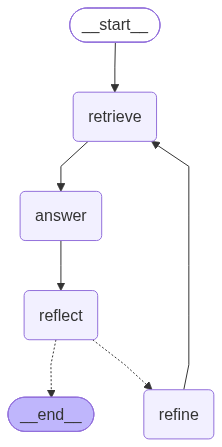

In [23]:
def should_continue(state: IterativeRAGState) -> str:
    """
    Conditional router after reflection:
      - 'refine' → answer was insufficient AND attempts < 2  (retry loop)
      - END      → answer verified OR max attempts reached   (stop)
    """
    if state.verified or state.attempts >= 2:
        return END
    return "refine"

builder = StateGraph(IterativeRAGState)

# ── Nodes ──
builder.add_node("retrieve", retrieve_docs)
builder.add_node("answer",   generate_answer)
builder.add_node("reflect",  reflect_on_answer)
builder.add_node("refine",   refine_query)

# ── Edges ──
builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "answer")
builder.add_edge("answer",   "reflect")

# Conditional: after reflection either stop or refine & retry
builder.add_conditional_edges(
    "reflect",
    should_continue,
    {"refine": "refine", END: END}   # explicit path_map
)

builder.add_edge("refine", "retrieve")  # loop back for another retrieval

graph = builder.compile()
graph

# Graph Visualization
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())


In [24]:
query = "agent loops  and transformer-based systems?"

initial_state = IterativeRAGState(question=query)
final = graph.invoke(initial_state)

print("✅ Final Answer:\n", final["answer"])
print("\n🧠 Verified:", final["verified"])
print("🔁 Attempts:", final["attempts"])


✅ Final Answer:
 Below is a concise comparison of **agent‑loop (tool‑augmented / retrieval‑augmented) systems** and **pure transformer‑based systems**, together with practical take‑aways that follow directly from the experiments you listed.

---

## 1. What each paradigm looks like in practice  

| Aspect | Agent‑Loop (Tool‑augmented prompting) | Pure Transformer‑based system |
|--------|--------------------------------------|------------------------------|
| **Core idea** | A language model is orchestrated by a **controller graph** (e.g., LangGraph) that can call external tools (SQL, Wikipedia, GraphQL, etc.) and route the output back to the model for further reasoning. | The model processes the whole input end‑to‑end, relying on its internal attention mechanisms (dense, sparse, or hybrid) to “remember” everything. |
| **Typical architecture** | `LLM → Planner → Tool(s) → Retriever/Executor → LLM (re‑prompt)` (often multiple iterations). | `Embedding → Encoder (e.g., EfficientFormer /